# Volatility Factor Analysis

## Research Objective
This notebook evaluates whether the volatility factor contains useful stock-selection information and whether lower-volatility stocks deliver more stable forward performance in the A-share market.


## Factor Definition
The volatility factor is measured using the rolling standard deviation of stock returns over a fixed lookback window. It is intended to capture the recent risk profile and price stability of individual stocks.

## Research Hypothesis
The working hypothesis is that lower-volatility stocks may deliver more stable forward returns on a risk-adjusted basis, while extremely high volatility may be associated with weaker signal reliability.

## Data and Test Design
The factor is reviewed through grouped return analysis, cumulative quantile comparison, and inspection of whether the risk-return trade-off is monotonic.


Initiating Volatility Factor Diagnostic...
Processing Snapshot: 2026-03-31

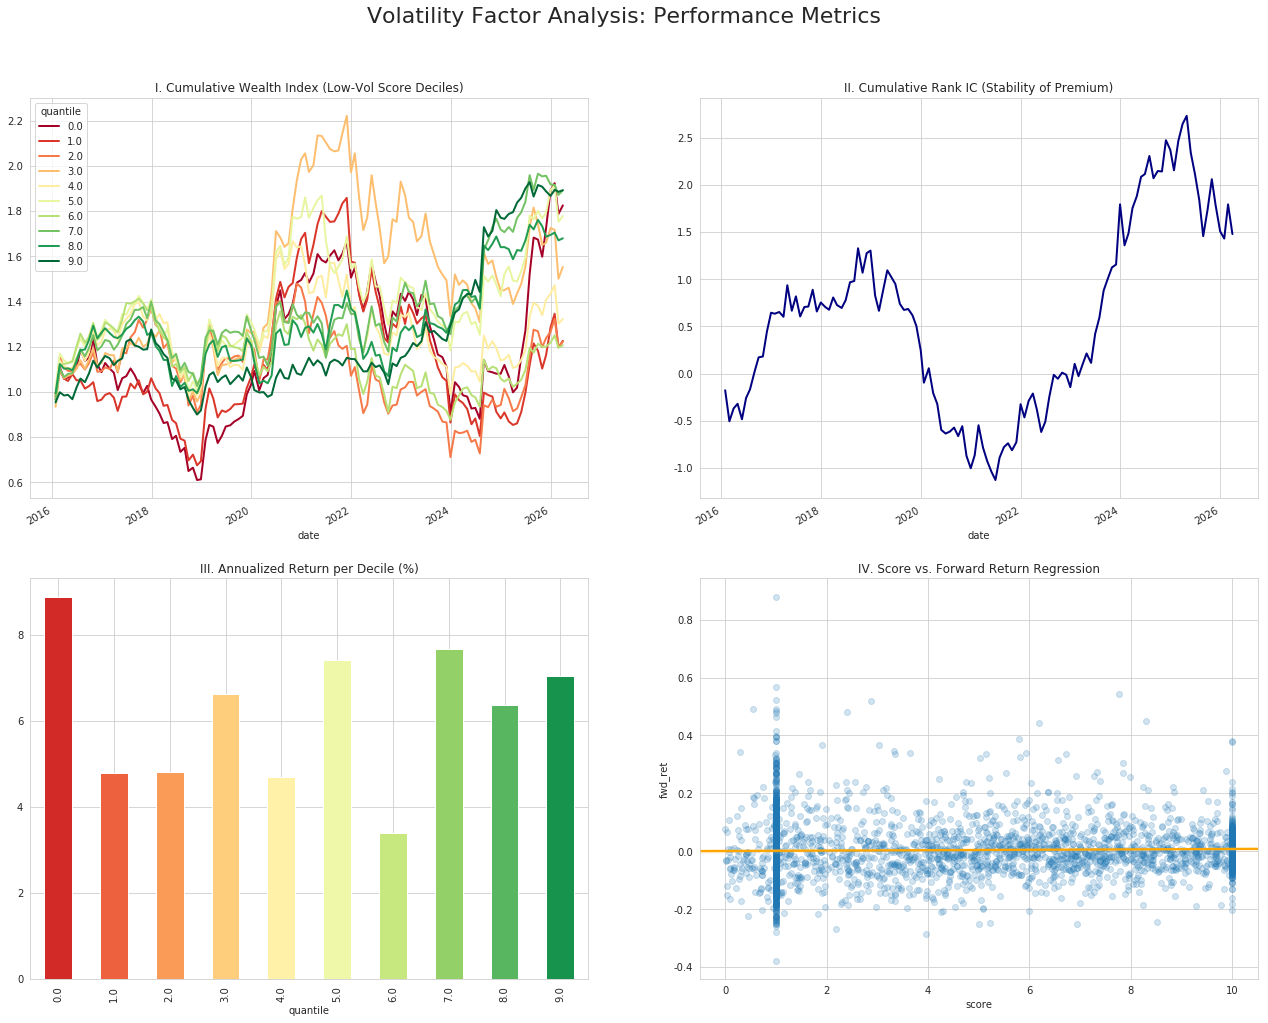

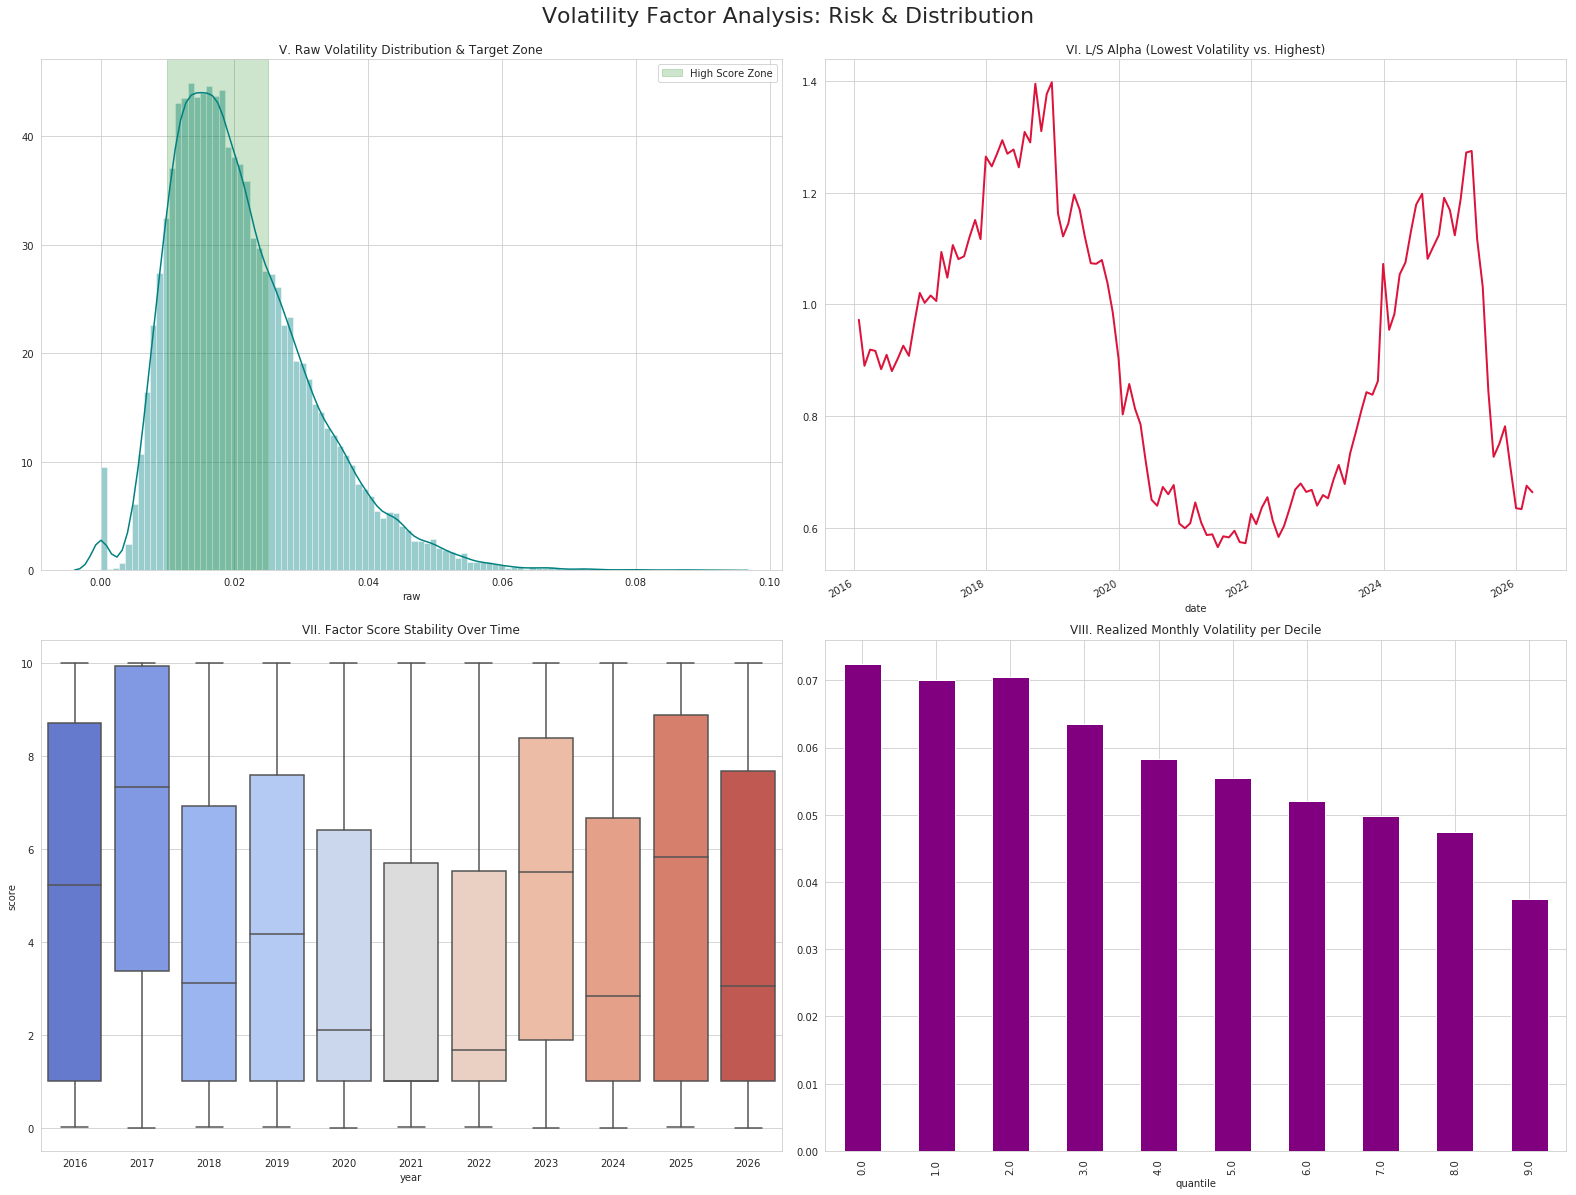


[Factor Report] Average IC: 0.0120 | ICIR: 0.0580


In [ ]:
'''
This factor is built on the "Low-Volatility Anomaly" logic, 
aiming to capture stocks with stable price action and strong defensive characteristics. 

By applying a reverse scoring mechanism (reverse=True), the model assigns 
higher scores to securities with lower realized volatility. 
In the A-share market, low-volatility stocks often outperform high-volatility 
counterparts over long horizons due to lower drawdown risk and steadier compounding.

This diagnostic analyzes the "Low-Vol" premium across the 000300.XSHG universe, 
evaluating whether the current optimal range effectively identifies 
the "stable winners" versus "speculative laggards.

It is worth noting that the monotonicity attenuation of this factor in the later stage 
of backtesting reflects the improvement in the pricing efficiency of high-volatility 
stocks during the institutionalization process of A-shares, suggesting that it is more 
suitable to be used as a constraint variable in portfolio optimization."
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
import warnings

# 1. Environment Configuration
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 2. Core Scoring Logic (Reverse Mapping)
def calculate_range_score(value, optimal_range, max_score, reverse=False):
    low, high = optimal_range
    if reverse:
        # Higher score for lower values (Defensive Logic)
        if value <= low: 
            return max_score
        elif value >= high: 
            return max_score * 0.1
        else: 
            return max_score * (1 - (value - low) / (high - low))
    else:
        if low <= value <= high: 
            return max_score
        elif value < low:
            return max_score * (value / low) if low > 0 else max_score * 0.3
        else:
            return max_score * (high / value) if value > 0 else max_score * 0.3

# 3. Parameters and Backtest Engine
start_date, end_date = "2016-01-01", "2026-04-01"
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

# Simulation Configuration
vol_period = 20    # 20-day rolling volatility
# Typical daily volatility for blue chips is often between 0.01 and 0.03
opt_range = (0.01, 0.025) 
weight = 10

dataset = []
print("Initiating Volatility Factor Diagnostic...")

for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i+1]
    universe = get_index_stocks('000300.XSHG', date=t0)
    print("\rProcessing Snapshot: {}".format(t0), end="")
    
    # Fetch historical prices (need +1 extra for log returns)
    prices = get_price(universe, end_date=t0, count=vol_period+1, fields='close', panel=False)
    
    res = []
    for s in universe:
        s_p = prices[prices['code'] == s]['close']
        if len(s_p) < vol_period: 
            continue
        # Calculate Log Returns Volatility
        returns = np.log(s_p / s_p.shift(1)).dropna()
        raw_vol = returns.std()
        
        score = calculate_range_score(raw_vol, opt_range, weight, reverse=True)
        res.append({'code': s, 'raw': raw_vol, 'score': score})
    
    if not res: continue
    
    df = pd.DataFrame(res)
    p0 = get_price(list(df['code']), end_date=t0, count=1, fields='close', panel=False).set_index('code')['close']
    p1 = get_price(list(df['code']), end_date=t1, count=1, fields='close', panel=False).set_index('code')['close']
    
    df['fwd_ret'] = df['code'].map((p1 / p0) - 1)
    df['date'] = pd.to_datetime(t0)
    dataset.append(df)

master_df = pd.concat(dataset, ignore_index=True).dropna()
master_df['year'] = master_df['date'].dt.year
master_df['quantile'] = master_df.groupby('date')['score'].transform(
    lambda x: pd.qcut(x.rank(method='first'), 10, labels=False)
)

# 4. Performance & Distribution Analysis (9-Plot System)
ic_ts = master_df.groupby('date').apply(lambda g: g['score'].corr(g['fwd_ret']))
q_ret = master_df.groupby(['date', 'quantile'])['fwd_ret'].mean().unstack()

# Plot Set 1: Return and IC
fig1, axes1 = plt.subplots(2, 2, figsize=(22, 18))
plt.suptitle('Volatility Factor Analysis: Performance Metrics', fontsize=22, y=0.95)

(1 + q_ret).cumprod().plot(ax=axes1[0, 0], colormap='RdYlGn', lw=2)
axes1[0, 0].set_title("I. Cumulative Wealth Index (Low-Vol Score Deciles)")

ic_ts.cumsum().plot(ax=axes1[0, 1], color='navy', lw=2)
axes1[0, 1].set_title("II. Cumulative Rank IC (Stability of Premium)")

(q_ret.mean() * 12 * 100).plot(kind='bar', color=sns.color_palette("RdYlGn", 10), ax=axes1[1, 0])
axes1[1, 0].set_title("III. Annualized Return per Decile (%)")

sns.regplot(x='score', y='fwd_ret', data=master_df.sample(min(len(master_df), 3000)), 
            ax=axes1[1, 1], scatter_kws={'alpha':0.2}, line_kws={'color':'orange'})
axes1[1, 1].set_title("IV. Score vs. Forward Return Regression")

# Plot Set 2: Distribution and Risk
fig2, axes2 = plt.subplots(2, 2, figsize=(22, 18))
plt.suptitle('Volatility Factor Analysis: Risk & Distribution', fontsize=22, y=0.95)

# V. Raw Value Distribution (Fixing histplot/distplot compatibility)
sns.distplot(master_df['raw'], bins=100, color='teal', ax=axes2[0, 0])
axes2[0, 0].axvspan(opt_range[0], opt_range[1], color='green', alpha=0.2, label='High Score Zone')
axes2[0, 0].set_title("V. Raw Volatility Distribution & Target Zone")
axes2[0, 0].legend()

# VI. Long-Short Alpha (G9 - G0)
(1 + (q_ret[9] - q_ret[0])).cumprod().plot(ax=axes2[0, 1], color='crimson', lw=2)
axes2[0, 1].set_title("VI. L/S Alpha (Lowest Volatility vs. Highest)")

# VII. Score Stability Boxplot
sns.boxplot(x='year', y='score', data=master_df, palette='coolwarm', ax=axes2[1, 0])
axes2[1, 0].set_title("VII. Factor Score Stability Over Time")

# VIII. Risk Attribution (Volatility of the Deciles)
q_ret.std().plot(kind='bar', color='purple', ax=axes2[1, 1])
axes2[1, 1].set_title("VIII. Realized Monthly Volatility per Decile")

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

print("\n[Factor Report] Average IC: {:.4f} | ICIR: {:.4f}".format(ic_ts.mean(), ic_ts.mean()/ic_ts.std()))